# Планаризация графа с минимизацией пересечений

Этот ноутбук:
1. Принимает произвольный граф (`networkx.Graph`) и ищет раскладку с минимумом пересечений рёбер.
2. Строит граф по вашей схеме (по приложенному изображению).
3. Показывает сравнение: исходная раскладка vs улучшенная раскладка.

In [11]:
import math
import random
from collections import defaultdict
from statistics import median
from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
import networkx as nx


Point = Tuple[float, float]
LayerMap = Dict[str, int]
LayerOrders = Dict[int, List[str]]


def _ccw(a: Point, b: Point, c: Point) -> float:
    return (b[0] - a[0]) * (c[1] - a[1]) - (b[1] - a[1]) * (c[0] - a[0])


def _segments_intersect(a: Point, b: Point, c: Point, d: Point, eps: float = 1e-12) -> bool:
    d1 = _ccw(a, b, c)
    d2 = _ccw(a, b, d)
    d3 = _ccw(c, d, a)
    d4 = _ccw(c, d, b)
    if abs(d1) < eps and abs(d2) < eps and abs(d3) < eps and abs(d4) < eps:
        return False
    return (d1 * d2 < 0) and (d3 * d4 < 0)


def count_crossings(g: nx.Graph, pos: Dict[str, Point]) -> int:
    edges = list(g.edges())
    crossings = 0
    for i in range(len(edges)):
        u1, v1 = edges[i]
        p1, p2 = pos[u1], pos[v1]
        for j in range(i + 1, len(edges)):
            u2, v2 = edges[j]
            if len({u1, v1, u2, v2}) < 4:
                continue
            p3, p4 = pos[u2], pos[v2]
            if _segments_intersect(p1, p2, p3, p4):
                crossings += 1
    return crossings


def _build_layers(levels: LayerMap) -> LayerOrders:
    layers: LayerOrders = defaultdict(list)
    for node, level in levels.items():
        layers[level].append(node)
    for level in layers:
        layers[level].sort()
    return dict(layers)


def _positions_from_orders(orders: LayerOrders, level_count: int, x_margin: float = 0.05) -> Dict[str, Point]:
    pos: Dict[str, Point] = {}
    y_step = 0.9 / max(level_count - 1, 1)

    for level in range(1, level_count + 1):
        layer_nodes = orders[level]
        n = len(layer_nodes)
        if n == 1:
            xs = [0.5]
        else:
            span = 1.0 - 2 * x_margin
            step = span / (n - 1)
            xs = [x_margin + i * step for i in range(n)]

        y = 0.95 - (level - 1) * y_step
        for idx, node in enumerate(layer_nodes):
            pos[node] = (xs[idx], y)
    return pos


def _adjacency_positions(order: List[str]) -> Dict[str, int]:
    return {node: idx for idx, node in enumerate(order)}


def _weighted_median_order(layer_nodes: List[str], neighbor_index: Dict[str, int], g: nx.Graph, levels: LayerMap, current_level: int) -> List[str]:
    decorated = []
    for node in layer_nodes:
        neighbors = [nbr for nbr in g.neighbors(node) if levels[nbr] != current_level and nbr in neighbor_index]
        if neighbors:
            key = float(median(neighbor_index[nbr] for nbr in neighbors))
        else:
            key = math.inf
        decorated.append((key, node))
    decorated.sort(key=lambda item: (item[0], item[1]))
    return [node for _, node in decorated]


def _score(g: nx.Graph, orders: LayerOrders, level_count: int) -> int:
    return count_crossings(g, _positions_from_orders(orders, level_count))


def planarize_layered_graph(
    g: nx.Graph,
    levels: LayerMap,
    level_count: int = 7,
    restarts: int = 60,
    iterations: int = 1400,
    seed: int = 42,
) -> Tuple[Dict[str, Point], int, LayerOrders]:
    """
    Планаризация для фиксированных уровней 1..7.
    Уровень вершины не меняется, меняется только порядок внутри слоя.
    Оптимизация идет в два этапа:
    1) стартовая медианная укладка;
    2) случайный локальный поиск с отжигом и финальным жадным улучшением.
    """
    missing = [node for node in g.nodes if node not in levels]
    if missing:
        raise ValueError(f"Для вершин не задан уровень: {missing}")

    rng = random.Random(seed)
    base_layers = _build_layers(levels)
    best_orders = None
    best_score = math.inf

    for _ in range(restarts):
        orders = {lvl: lst[:] for lvl, lst in base_layers.items()}
        for lvl in range(1, level_count + 1):
            rng.shuffle(orders[lvl])

        for _ in range(6):
            for lvl in range(2, level_count + 1):
                orders[lvl] = _weighted_median_order(orders[lvl], _adjacency_positions(orders[lvl - 1]), g, levels, lvl)
            for lvl in range(level_count - 1, 0, -1):
                orders[lvl] = _weighted_median_order(orders[lvl], _adjacency_positions(orders[lvl + 1]), g, levels, lvl)

        current = {lvl: lst[:] for lvl, lst in orders.items()}
        current_score = _score(g, current, level_count)
        temperature = 5.0

        for step in range(iterations):
            level = rng.randint(1, level_count)
            layer = current[level]
            if len(layer) < 2:
                temperature *= 0.995
                continue

            proposal = {lvl: lst[:] for lvl, lst in current.items()}
            if rng.random() < 0.8:
                i = rng.randrange(len(layer) - 1)
                proposal[level][i], proposal[level][i + 1] = proposal[level][i + 1], proposal[level][i]
            else:
                i = rng.randrange(len(layer))
                j = rng.randrange(len(layer))
                if i != j:
                    node = proposal[level].pop(i)
                    proposal[level].insert(j, node)

            proposal_score = _score(g, proposal, level_count)
            delta = proposal_score - current_score
            if delta <= 0 or rng.random() < math.exp(-delta / max(temperature, 1e-6)):
                current = proposal
                current_score = proposal_score

            temperature *= 0.996

        improved = True
        while improved:
            improved = False
            for lvl in range(1, level_count + 1):
                layer = current[lvl]
                for i in range(len(layer) - 1):
                    proposal = {k: v[:] for k, v in current.items()}
                    proposal[lvl][i], proposal[lvl][i + 1] = proposal[lvl][i + 1], proposal[lvl][i]
                    proposal_score = _score(g, proposal, level_count)
                    if proposal_score < current_score:
                        current = proposal
                        current_score = proposal_score
                        improved = True

        if current_score < best_score:
            best_score = current_score
            best_orders = {lvl: lst[:] for lvl, lst in current.items()}
            if best_score == 0:
                break

    best_pos = _positions_from_orders(best_orders, level_count)
    return best_pos, int(best_score), best_orders


def draw_graph(g: nx.Graph, pos: Dict[str, Point], title: str) -> None:
    plt.figure(figsize=(18, 10))
    nx.draw_networkx_nodes(g, pos, node_size=1700, node_color="#ececec", edgecolors="#222")
    nx.draw_networkx_labels(g, pos, font_size=8)
    nx.draw_networkx_edges(g, pos, width=1.4, edge_color="#111")
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

Пересечений в базовой layered-раскладке: 63
Пересечений после layered-планаризации: 13

Порядок вершин по уровням после оптимизации:
Уровень 1: ['Статус Участия', 'Роль', 'Статус Соревнования', 'Статус Команды', 'Метрика', 'Тип задачи', 'Роль в команде', 'Назначение датасета', 'Статус Обработка']
Уровень 2: ['Пользователь', 'Датасет']
Уровень 3: ['Соревнование', 'Файл датасета']
Уровень 4: ['Команда', 'Конфигурации', 'Датасет в соревновании']
Уровень 5: ['Участие', 'Команда в соревновании', 'Участие в команде']
Уровень 6: ['Позиция в рейтинге', 'Попытка']
Уровень 7: ['Оценка', 'Код решения']


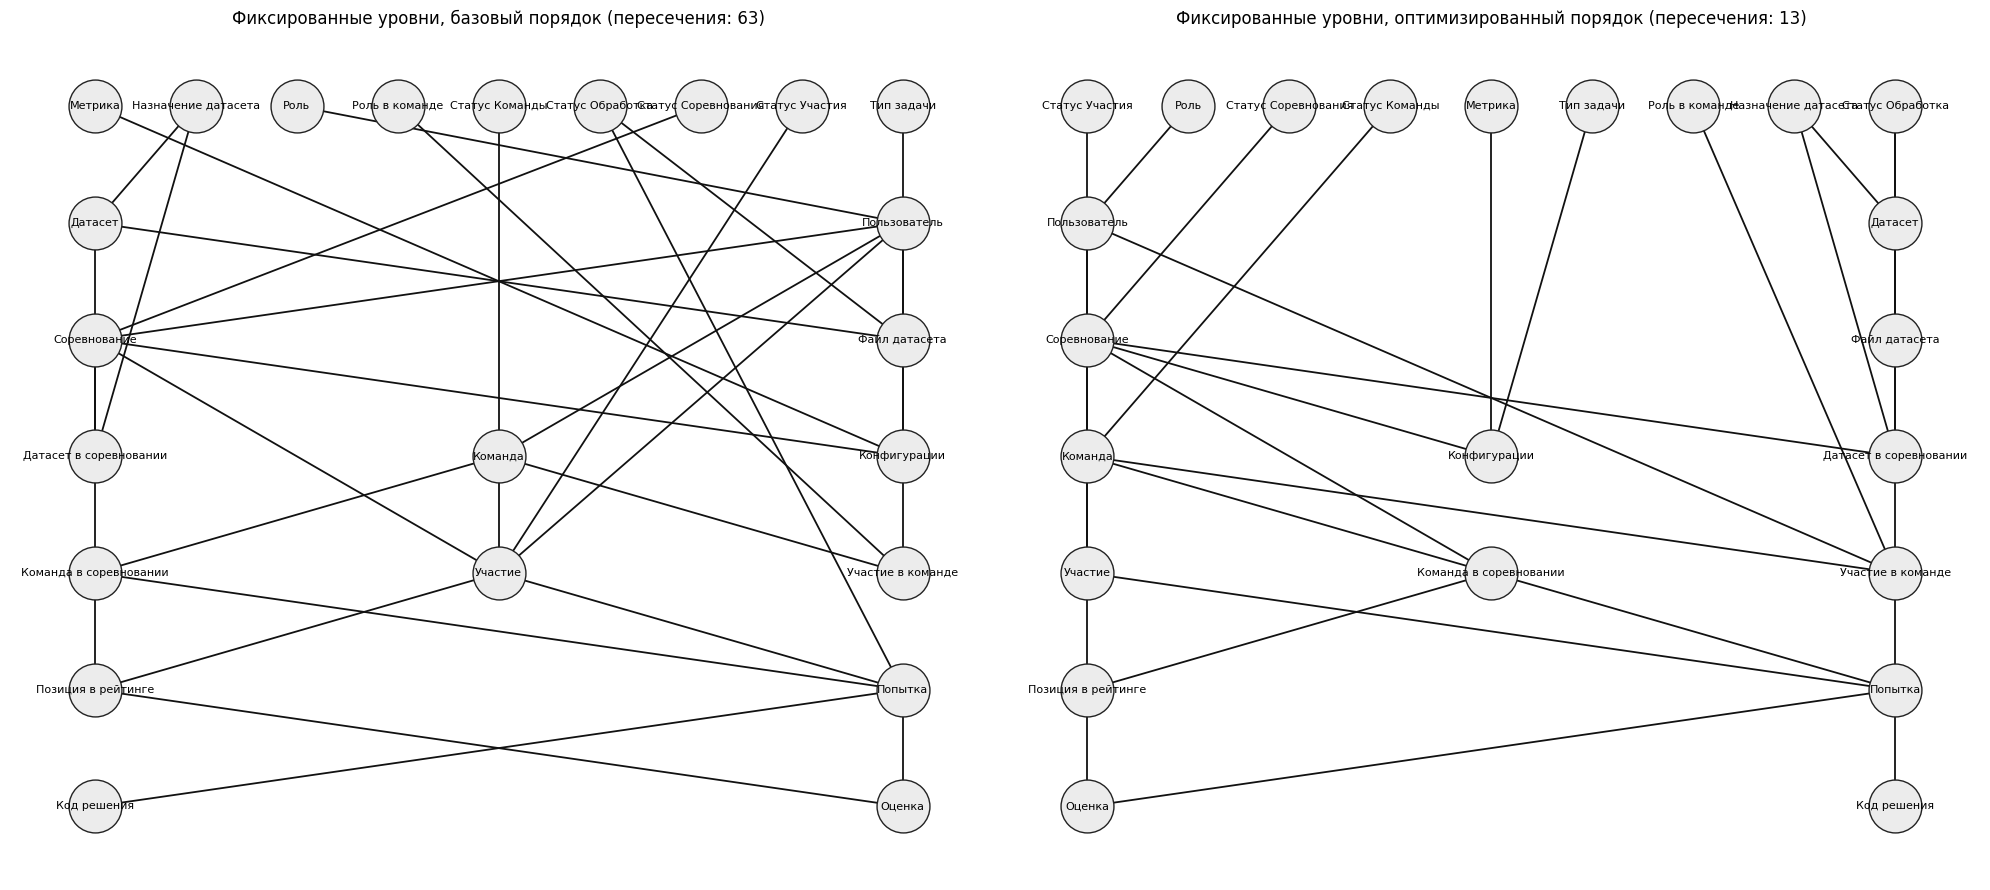

In [12]:
# --- Граф по схеме + фиксированная иерархия уровней 1..7 ---

nodes = [
    "Статус Обработка",
    "Статус Участия",
    "Роль",
    "Статус Соревнования",
    "Назначение датасета",
    "Роль в команде",
    "Метрика",
    "Тип задачи",
    "Статус Команды",
    "Пользователь",
    "Датасет",
    "Файл датасета",
    "Соревнование",
    "Датасет в соревновании",
    "Конфигурации",
    "Команда",
    "Участие",
    "Участие в команде",
    "Команда в соревновании",
    "Попытка",
    "Позиция в рейтинге",
    "Код решения",
    "Оценка",
]

edges = [
    ("Пользователь", "Роль"),

    ("Файл датасета", "Датасет"),
    ("Файл датасета", "Статус Обработка"),
    ("Датасет", "Назначение датасета"),

    ("Соревнование", "Пользователь"),
    ("Соревнование", "Статус Соревнования"),

    ("Конфигурации", "Соревнование"),
    ("Конфигурации", "Метрика"),
    ("Конфигурации", "Тип задачи"),

    ("Датасет в соревновании", "Соревнование"),
    ("Датасет в соревновании", "Датасет"),
    ("Датасет в соревновании", "Назначение датасета"),

    ("Команда", "Статус Команды"),
    ("Команда", "Пользователь"),
    ("Команда в соревновании", "Команда"),
    ("Команда в соревновании", "Соревнование"),
    ("Участие в команде", "Команда"),
    ("Участие в команде", "Пользователь"),
    ("Участие в команде", "Роль в команде"),

    ("Участие", "Пользователь"),
    ("Участие", "Соревнование"),
    ("Участие", "Статус Участия"),
    ("Участие", "Команда"),

    ("Попытка", "Участие"),
    ("Попытка", "Статус Обработка"),
    ("Попытка", "Команда в соревновании"),

    ("Оценка", "Попытка"),
    ("Код решения", "Попытка"),
    ("Позиция в рейтинге", "Участие"),
    ("Позиция в рейтинге", "Команда в соревновании"),
    ("Позиция в рейтинге", "Оценка"),
]

levels = {
    "Статус Обработка": 1,
    "Статус Участия": 1,
    "Роль": 1,
    "Статус Соревнования": 1,
    "Назначение датасета": 1,
    "Роль в команде": 1,
    "Метрика": 1,
    "Тип задачи": 1,
    "Статус Команды": 1,
    "Пользователь": 2,
    "Датасет": 2,
    "Файл датасета": 3,
    "Соревнование": 3,
    "Датасет в соревновании": 4,
    "Конфигурации": 4,
    "Команда": 4,
    "Участие": 5,
    "Участие в команде": 5,
    "Команда в соревновании": 5,
    "Попытка": 6,
    "Позиция в рейтинге": 6,
    "Код решения": 7,
    "Оценка": 7,
}

G = nx.Graph()
G.add_nodes_from(nodes)
G.add_edges_from(edges)

base_orders = {}
for lvl in range(1, 8):
    base_orders[lvl] = sorted([n for n, l in levels.items() if l == lvl])

base_pos = _positions_from_orders(base_orders, level_count=7)
base_crossings = count_crossings(G, base_pos)

best_pos, min_crossings, best_orders = planarize_layered_graph(
    G,
    levels=levels,
    level_count=7,
    restarts=100,
    iterations=2200,
    seed=42,
)

print(f"Пересечений в базовой layered-раскладке: {base_crossings}")
print(f"Пересечений после layered-планаризации: {min_crossings}")

print("\nПорядок вершин по уровням после оптимизации:")
for lvl in range(1, 8):
    print(f"Уровень {lvl}: {best_orders[lvl]}")

plt.figure(figsize=(20, 9))

plt.subplot(1, 2, 1)
nx.draw_networkx_nodes(G, base_pos, node_size=1450, node_color="#ececec", edgecolors="#222")
nx.draw_networkx_labels(G, base_pos, font_size=8)
nx.draw_networkx_edges(G, base_pos, width=1.3, edge_color="#111")
plt.title(f"Фиксированные уровни, базовый порядок (пересечения: {base_crossings})")
plt.axis("off")

plt.subplot(1, 2, 2)
nx.draw_networkx_nodes(G, best_pos, node_size=1450, node_color="#ececec", edgecolors="#222")
nx.draw_networkx_labels(G, best_pos, font_size=8)
nx.draw_networkx_edges(G, best_pos, width=1.3, edge_color="#111")
plt.title(f"Фиксированные уровни, оптимизированный порядок (пересечения: {min_crossings})")
plt.axis("off")

plt.tight_layout()
plt.show()

# Универсальное применение к другому графу:
# my_g = nx.Graph()
# my_g.add_edges_from([...])
# my_levels = {"A": 1, "B": 2, "C": 2, "D": 3}
# my_pos, my_cross, my_orders = planarize_layered_graph(my_g, my_levels, level_count=3)
# draw_graph(my_g, my_pos, f"Layered-planarization, crossings={my_cross}")